In [83]:
# Phase 2 – Application – Analyse du dataset de santé
import pandas as pd

df = pd.read_csv("health.csv")
df

,Unnamed: 0,Year,Country,Spending_USD,Life_Expectancy
0,0,1970,Germany,252.311,70.6
1,1,1970,France,192.143,72.2
2,2,1970,Great Britain,123.993,71.9
3,3,1970,Japan,150.437,72.0
4,4,1970,USA,326.961,70.9
...,...,...,...,...,...
269,269,2020,Germany,6938.983,81.1
270,270,2020,France,5468.418,82.3
271,271,2020,Great Britain,5018.700,80.4
272,272,2020,Japan,4665.641,84.7


In [84]:
print(df.dtypes)

Unnamed: 0           int64
Year                 int64
Country                str
Spending_USD       float64
Life_Expectancy    float64
dtype: object


In [8]:

print(df["Country"].value_counts())

Country
Japan            51
USA              51
Germany          50
Canada           44
Great Britain    43
France           35
Name: count, dtype: int64


In [85]:
df["Spending_USD"].describe()

count      274.000000
mean      2789.338905
std       2194.939785
min        123.993000
25%       1038.357000
50%       2295.578000
75%       4055.610000
max      11859.179000
Name: Spending_USD, dtype: float64

In [9]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


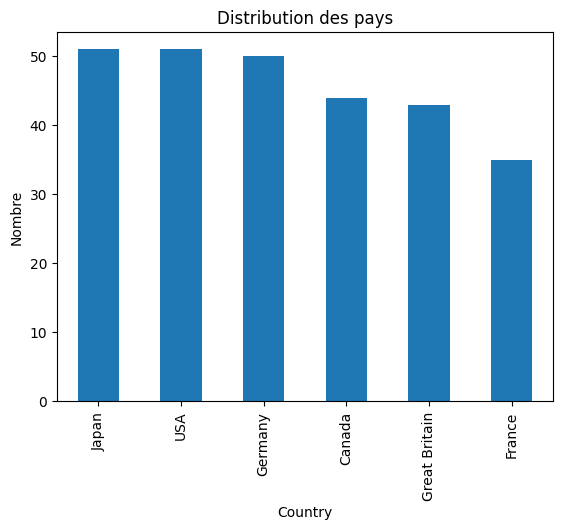

In [10]:
import matplotlib.pyplot as plt

df["Country"].value_counts().plot(kind='bar')
plt.title("Distribution des pays")
plt.xlabel("Country")
plt.ylabel("Nombre")
plt.show()

In [11]:
print(df["Spending_USD"].describe())

count      274.000000
mean      2789.338905
std       2194.939785
min        123.993000
25%       1038.357000
50%       2295.578000
75%       4055.610000
max      11859.179000
Name: Spending_USD, dtype: float64


Text(0.5, 1.0, 'Boxplot de Spending_USD')

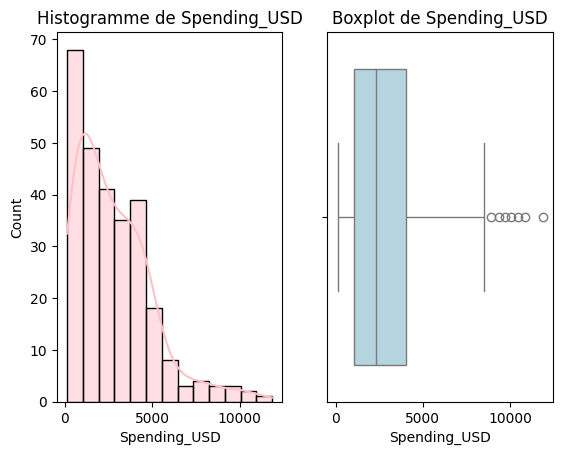

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.subplot(1,2,1)
sns.histplot(df["Spending_USD"], color="pink", kde=True)
plt.title("Histogramme de Spending_USD")

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=df["Spending_USD"], color="lightblue")
plt.title("Boxplot de Spending_USD")


In [13]:
print(df["Life_Expectancy"].describe())

count    274.000000
mean      77.909489
std        3.276263
min       70.600000
25%       75.525000
50%       78.100000
75%       80.575000
max       84.700000
Name: Life_Expectancy, dtype: float64


<Axes: xlabel='Year', ylabel='Life_Expectancy'>

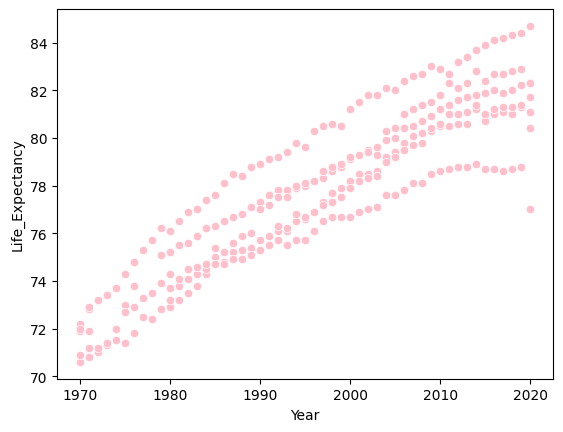

In [14]:
import matplotlib.pyplot as plt 
import seaborn as sns

sns.scatterplot(x=df["Year"], y=df["Life_Expectancy"], color="pink")


<Axes: xlabel='Year', ylabel='Spending_USD'>

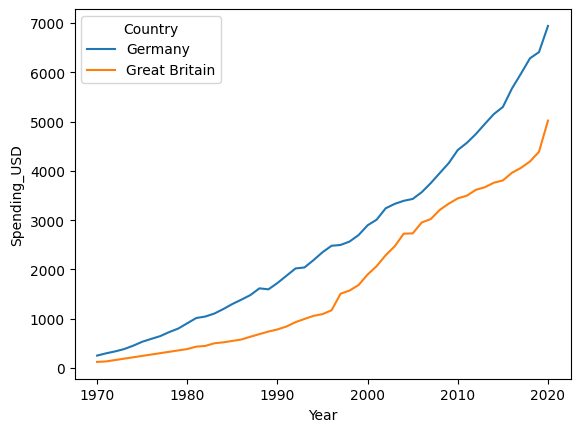

In [15]:
#sns.displot(data = df,)
comparaison_df = df[df["Country"].isin (["Germany" , "Great Britain"])]
sns.lineplot (data =comparaison_df, x ="Year" , y = "Spending_USD", hue = "Country") 


<Axes: xlabel='Country', ylabel='Life_Expectancy'>

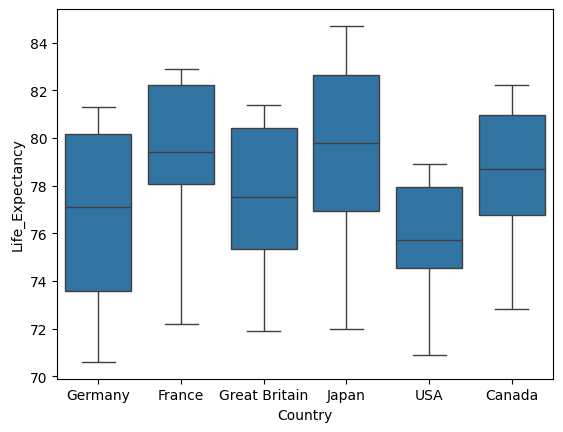

In [16]:

sns.boxplot(data=df, x="Country", y="Life_Expectancy")

<Axes: xlabel='Country', ylabel='Life_Expectancy'>

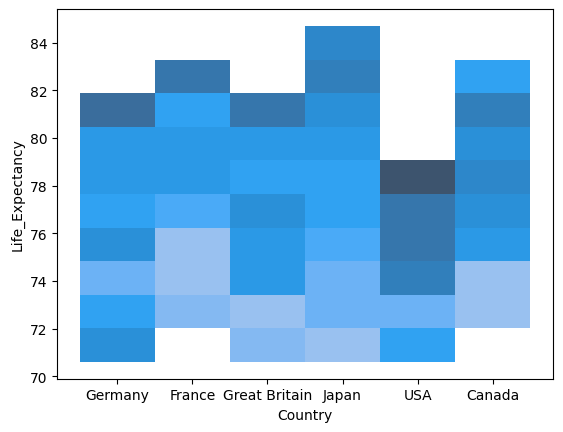

In [17]:
sns.histplot(data=df, x="Country", y="Life_Expectancy" )

<Axes: xlabel='Life_Expectancy', ylabel='Spending_USD'>

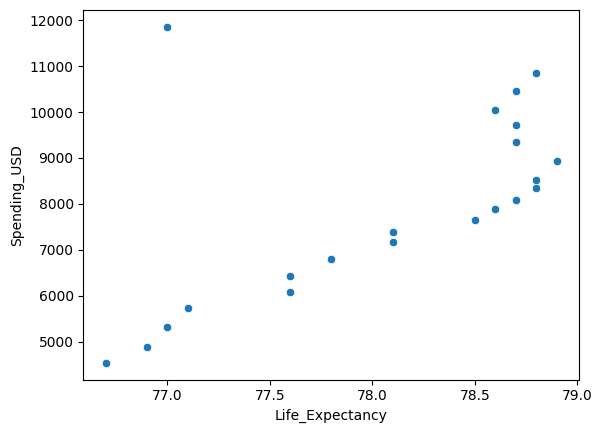

In [18]:
#la relation entre la durée de vie et les dépenses dans la santé, aux États-Unis, de 2000 à 2020
usa_df = df [(df["Country"]=="USA")&(df["Year"] >= 2000) & (df["Year"] <= 2020)]
sns.scatterplot(data=usa_df ,x= "Life_Expectancy", y="Spending_USD") 


In [19]:
#Analyses statistiques avancées :

#Calculez la corrélation de Pearson entre ces deux variables aux États-Unis (2000–2020)
 
from scipy.stats import pearsonr

# Filtrer USA (2000–2020)
usa_df = df[(df["Country"] == "USA") & 
            (df["Year"] >= 2000) & 
            (df["Year"] <= 2020)]

# Corrélation de Pearson
r = pearsonr(usa_df["Life_Expectancy"], usa_df["Spending_USD"])

print(r)


PearsonRResult(statistic=np.float64(0.6210674528998253), pvalue=np.float64(0.0026581544805799064))


In [20]:
usa_df["diff_life"] = usa_df["Life_Expectancy"].diff()

In [22]:
import pandas as pd
import seaborn as sns
from scipy import stats


# Filtrer USA depuis 1970
usa_df = df[(df["Country"] == "USA") & (df["Year"] >= 1970)].sort_values("Year")

# Calcul des variations
usa_df["diff_life"] = usa_df["Life_Expectancy"].diff()

# Nettoyage
diffs = usa_df["diff_life"].dropna()

# Moyenne observée
mean_diff = diffs.mean()

# Test t
t_stat, p_value = stats.ttest_1samp(diffs, 0.3)

print("Moyenne observée :", mean_diff)
print("t-stat :", t_stat)
print("p-value :", p_value)

Moyenne observée : 0.12199999999999989
t-stat : -3.7212105613188773
p-value : 0.000511201324919395


In [24]:
#Phase 3 – Application – Dataset MPG

In [26]:
df = sns.load_dataset ("mpg")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


# 1-Quelles sont les variables discrètes et continues de ce dataset ?

#les variables discretes 
'cylinders', 'origin', 'model_year'
les variables continues
'mpg', 'displacement', 'horsepower', 'weight', 'acceleration'

In [28]:
#2-Analyse de mpg

df["mpg"].describe()

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

En moyenne, les voitures de ce dataset parcourent 23.51 miles avec 1 gallon d'essence.

Text(0.5, 1.0, 'Boxplot de mpg')

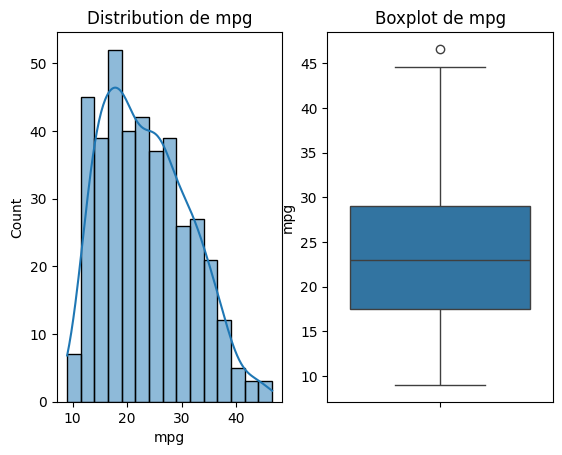

In [42]:
plt.subplot(1,2,1)
sns.histplot(df['mpg'], kde=True, bins=15)
plt.title("Distribution de mpg")

plt.subplot(1,2,2)
sns.boxplot(y=df['mpg'])
plt.title("Boxplot de mpg")


In [31]:
#Analysez la variable cylinders

df["cylinders"].value_counts()

cylinders
4    204
8    103
6     84
3      4
5      3
Name: count, dtype: int64

In [ ]:
#Analysez la variable origin
df["origin"].value_counts()

origin
usa       249
japan      79
europe     70
Name: count, dtype: int64

Text(0.5, 1.0, 'horsepower vs- origin ')

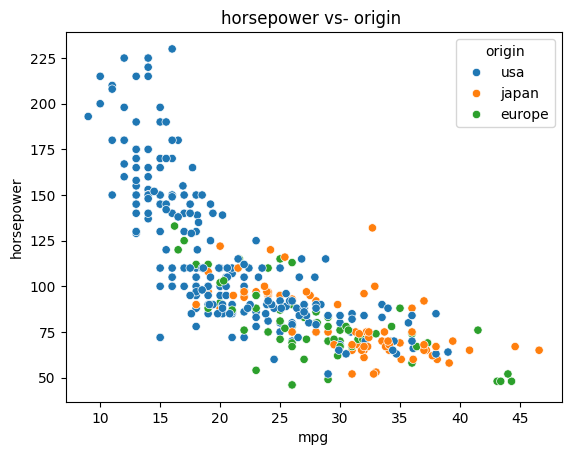

In [ ]:
#Observez l'évolution de la consommation des voitures (mpg) par rapport au nombre de chevaux (horsepower)

sns.scatterplot(data=df ,x = df["mpg"],y =df["horsepower"] ,hue ="origin")
plt.title("horsepower vs origin ")



#Que semble-t-on voir ?
L'origine géographique influence fortement la puissance et la consommation d'une voiture.

Text(0.5, 1.0, 'horsepower vs origin ')

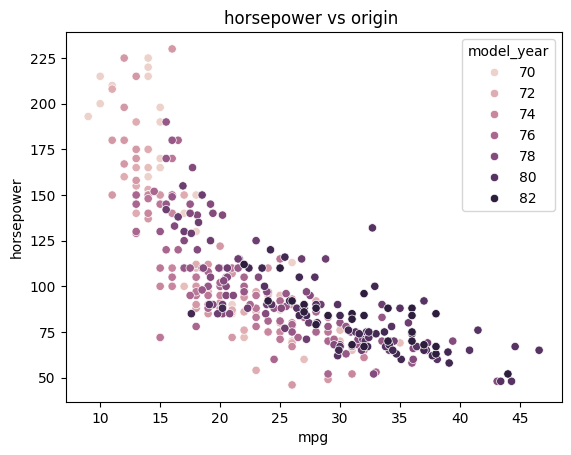

In [49]:
#Rajoutez-y la variable de l'année du modèle. Que voit-on ?
sns.scatterplot(data=df ,x = df["mpg"],y =df["horsepower"] ,hue ="model_year")
plt.title("horsepower vs origin ")


<Axes: xlabel='model_year', ylabel='weight'>

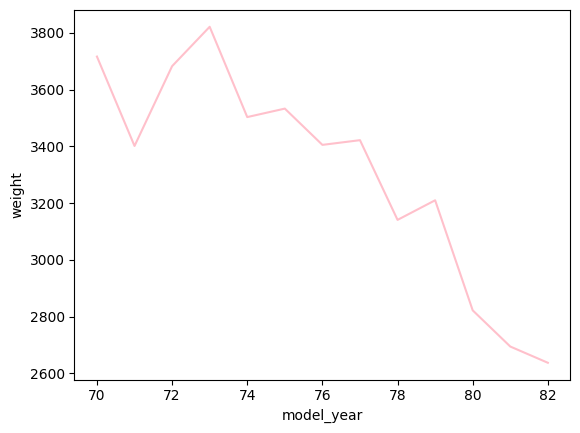

In [56]:
#Observez l'évolution du poids moyen des voitures américaines de l'année 70 jusqu'à l'année 82.

usa_df = df[df["origin"] == "usa"]

# Grouper par année et calculer le poids moyen
usa_poids = usa_df.groupby("model_year")["weight"].mean().reset_index()
sns.lineplot(data=usa_poids ,x ="model_year", y = "weight", color ="pink")



on peut deduire que le poid moyen est en dimunition en fonction de temps  à cause du choc pétrolier de 1973 

In [57]:
#Analysez la relation entre le nombre de cylindres et l'année du modèle.
pd.crosstab(df["cylinders"],df["model_year"])

model_year,70,71,72,73,74,75,76,77,78,79,80,81,82
cylinders,,,,,,,,,,,,,
3,0,0,1,1,0,0,0,1,0,0,1,0,0
4,7,13,14,11,15,12,15,14,17,12,25,21,28
5,0,0,0,0,0,0,0,0,1,1,1,0,0
6,4,8,0,8,7,12,10,5,12,6,2,7,3
8,18,7,13,20,5,6,9,8,6,10,0,1,0


Text(0.5, 1.0, "Nombre de cylindres selon l'année du modèle")

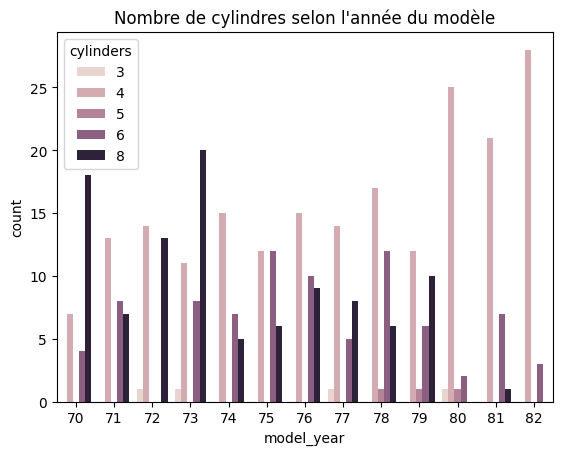

In [62]:
sns.countplot(data =df ,x="model_year",hue="cylinders")
plt.title("Nombre de cylindres selon l'année du modèle")


Text(0.5, 1.0, "la relation entre le nombre de cylindres et l'origine")

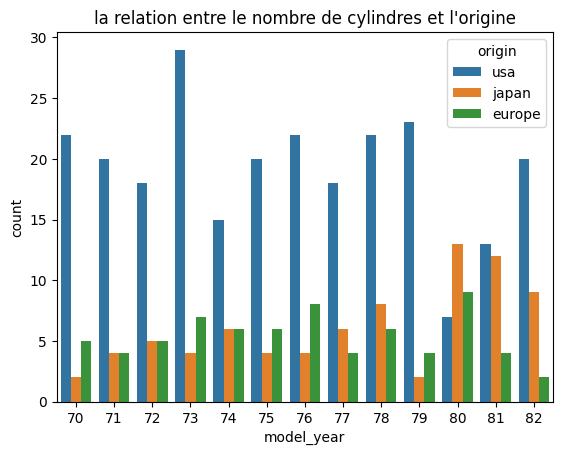

In [63]:
sns.countplot(data =df ,x="model_year",hue="origin")
plt.title("la relation entre le nombre de cylindres et l'origine")


d apres le graphe on peut voir que USA domine toujours ms il baisse progressivemnt ,Tandis que japan rest stable au contraire de japan augmente progressivemnt 

In [ ]:
#Quelle est l'accélération moyenne des voitures des différents pays ?
df["acceleration"].describe()

count    398.000000
mean      15.568090
std        2.757689
min        8.000000
25%       13.825000
50%       15.500000
75%       17.175000
max       24.800000
Name: acceleration, dtype: float64

In [ ]:
#Quelle est l'accélération moyenne des voitures des différents pays ?
df.groupby("origin")["acceleration"].mean()

origin
europe    16.787143
japan     16.172152
usa       15.033735
Name: acceleration, dtype: float64

In [ ]:
#Quelle est-elle pour les modèles de l'année 80 ?
acc =df[df["model_year"]==80].groupby("origin")["acceleration"].mean()
print(acc)


origin
europe    18.366667
japan     16.015385
usa       16.800000
Name: acceleration, dtype: float64


In [ ]:

df[df["model_year"] == 80]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
309,41.5,4,98.0,76.0,2144,14.7,80,europe,vw rabbit
310,38.1,4,89.0,60.0,1968,18.8,80,japan,toyota corolla tercel
311,32.1,4,98.0,70.0,2120,15.5,80,usa,chevrolet chevette
312,37.2,4,86.0,65.0,2019,16.4,80,japan,datsun 310
313,28.0,4,151.0,90.0,2678,16.5,80,usa,chevrolet citation
314,26.4,4,140.0,88.0,2870,18.1,80,usa,ford fairmont
315,24.3,4,151.0,90.0,3003,20.1,80,usa,amc concord
316,19.1,6,225.0,90.0,3381,18.7,80,usa,dodge aspen
317,34.3,4,97.0,78.0,2188,15.8,80,europe,audi 4000
318,29.8,4,134.0,90.0,2711,15.5,80,japan,toyota corona liftback
